# Add Sharadar Metadata to LSEG Fundamentals CSV

This notebook enriches your LSEG fundamentals CSV with Sharadar ticker metadata (exchange, category, ADR status, sector, industry, market cap scale, etc.) so that all information is available in a single database table for Pipeline filtering.

## Metadata Columns Added

The following columns will be added with `sharadar_` prefix:

- `sharadar_exchange`: Exchange (NYSE, NASDAQ, NYSEMKT, etc.)
- `sharadar_category`: Stock category (Domestic Common Stock, ADR, ETF, etc.)
- `sharadar_is_adr`: Boolean ADR flag (1=True, 0=False)
- `sharadar_location`: Company location (USA, etc.)
- `sharadar_sector`: Sharadar sector
- `sharadar_industry`: Sharadar industry
- `sharadar_sicsector`: SIC sector
- `sharadar_sicindustry`: SIC industry
- `sharadar_scalemarketcap`: Market cap scale (1-6: Nano to Mega)

## Author
Kamran Sokhanvari / Hidden Point Capital

## 1. Setup and Configuration

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load Sharadar Ticker Metadata

In [2]:
# Import functions from the script (single source of truth with deduplication fix)
import sys
sys.path.insert(0, '/app/examples/lseg_fundamentals')
from add_sharadar_metadata_to_fundamentals import (
    load_sharadar_tickers, 
    add_metadata_to_fundamentals,
    find_newest_csv,
    generate_output_filename
)

print("✓ Imported functions from add_sharadar_metadata_to_fundamentals.py")
print("  - load_sharadar_tickers() - loads and deduplicates Sharadar metadata")
print("  - add_metadata_to_fundamentals() - merges metadata with fundamentals")
print("  - find_newest_csv() - auto-detects newest CSV by date in filename")
print("  - generate_output_filename() - auto-generates output filename")
print("\n⚠️  DEDUPLICATION FIX: Handles multiple entries per ticker (keeps first occurrence)")

✓ Imported functions from add_sharadar_metadata_to_fundamentals.py
  - load_sharadar_tickers() - loads and deduplicates Sharadar metadata
  - add_metadata_to_fundamentals() - merges metadata with fundamentals
  - find_newest_csv() - auto-detects newest CSV by date in filename
  - generate_output_filename() - auto-generates output filename

⚠️  DEDUPLICATION FIX: Handles multiple entries per ticker (keeps first occurrence)


In [3]:
# Configuration
CSV_DIR = '/data/csv/'  # Directory containing LSEG fundamentals CSV files
SHARADAR_BUNDLE = 'sharadar'  # Sharadar bundle name

# Auto-detect newest CSV file by date in filename
print("Auto-detecting newest CSV file...")
INPUT_CSV = find_newest_csv(directory=CSV_DIR)

if INPUT_CSV is None:
    raise FileNotFoundError(f"No CSV files found in {CSV_DIR}")

# Auto-generate output filename
OUTPUT_CSV = generate_output_filename(INPUT_CSV)

print(f"Input CSV: {INPUT_CSV}")
print(f"Output CSV: {OUTPUT_CSV}")
print(f"Sharadar Bundle: {SHARADAR_BUNDLE}")

Auto-detecting newest CSV file...
Found 3 CSV files in /data/csv
  20091231_20260113.csv: 20091231 to 20260113

Newest file: 20091231_20260113.csv (20091231 to 20260113)
Input CSV: /data/csv/20091231_20260113.csv
Output CSV: /data/csv/20091231_20260113_with_metadata.csv
Sharadar Bundle: sharadar


In [4]:
# Load Sharadar metadata
sharadar_metadata = load_sharadar_tickers(SHARADAR_BUNDLE)

print(f"\nMetadata shape: {sharadar_metadata.shape}")
print(f"\nColumns: {list(sharadar_metadata.columns)}")
print(f"\nFirst 5 rows:")
sharadar_metadata.head()

Loading Sharadar tickers metadata...


Loaded 60672 tickers
After deduplication: 31093 unique tickers

Metadata shape: (31093, 10)

Columns: ['Symbol', 'exchange', 'category', 'location', 'sector', 'industry', 'sicsector', 'sicindustry', 'scalemarketcap', 'is_adr']

First 5 rows:


,Symbol,exchange,category,location,sector,industry,sicsector,sicindustry,scalemarketcap,is_adr
None,,,,,,,,,,
0,CRMX,BATS,ETF,Wisconsin; U.S.A,None,None,None,None,None,0
1,PATX,BATS,ETF,Wisconsin; U.S.A,None,None,None,None,None,0
2,ONDU,BATS,ETF,Wisconsin; U.S.A,None,None,None,None,None,0
3,UUUG,NASDAQ,ETF,Connecticut; U.S.A,None,None,None,None,None,0
4,USGG,NASDAQ,ETF,Connecticut; U.S.A,None,None,None,None,None,0


## 3. Metadata Summary Statistics

EXCHANGE DISTRIBUTION
exchange
NASDAQ      15748
NYSE         8510
NYSEARCA     3845
NYSEMKT      1502
BATS         1476
OTC             6
INDEX           5
Name: count, dtype: int64


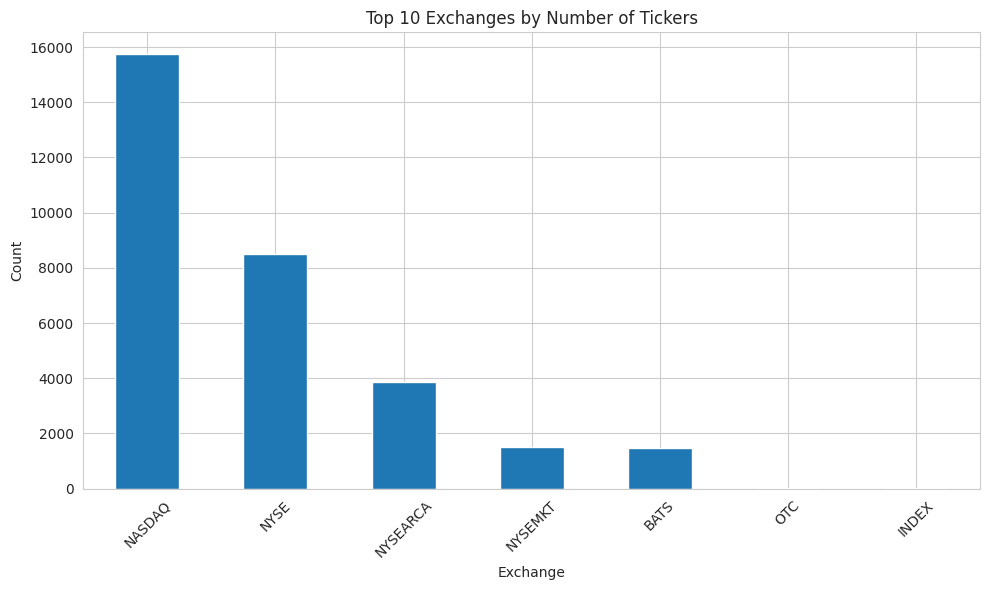

In [5]:
# Exchange distribution
print("=" * 80)
print("EXCHANGE DISTRIBUTION")
print("=" * 80)
print(sharadar_metadata['exchange'].value_counts())

# Plot
plt.figure(figsize=(10, 6))
sharadar_metadata['exchange'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Exchanges by Number of Tickers')
plt.xlabel('Exchange')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

CATEGORY DISTRIBUTION
category
Domestic Common Stock                    13417
ETF                                       6749
Domestic Common Stock Primary Class       2045
ADR Common Stock                          1821
Domestic Common Stock Warrant             1487
Domestic Common Stock Secondary Class     1198
Domestic Preferred Stock                  1120
CEF                                       1068
ETD                                        480
ETN                                        412
Canadian Common Stock                      370
ADR Common Stock Primary Class             258
ADR Common Stock Warrant                   226
ADR Common Stock Secondary Class           152
ADR Preferred Stock                         91
CEF Preferred                               69
CEF Warrant                                 52
UNIT                                        24
ETMF                                        18
Canadian Common Stock Primary Class         15
Canadian Common Stock Warrant

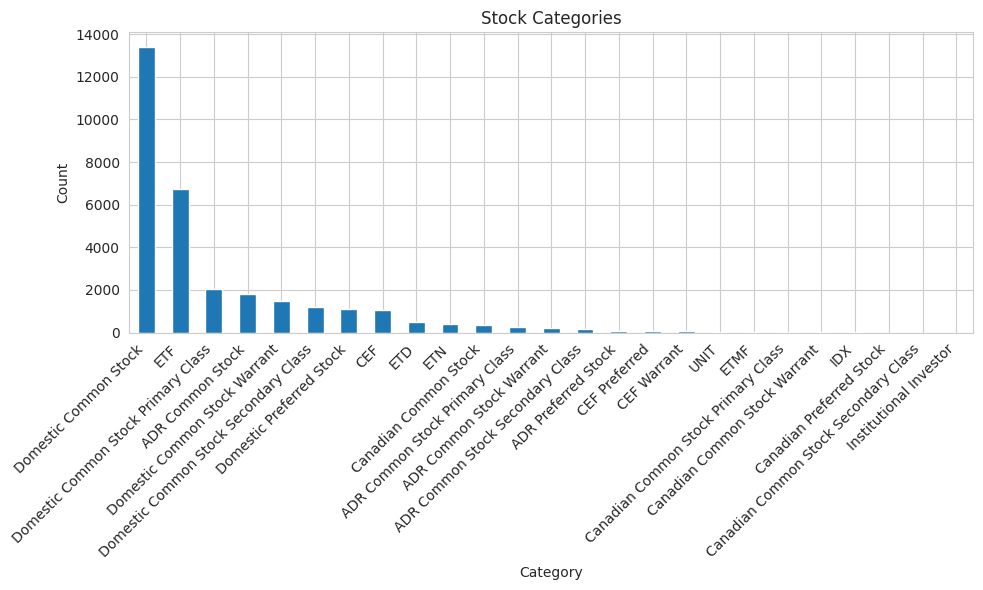

In [6]:
# Category distribution
print("=" * 80)
print("CATEGORY DISTRIBUTION")
print("=" * 80)
print(sharadar_metadata['category'].value_counts())

# Plot
plt.figure(figsize=(10, 6))
sharadar_metadata['category'].value_counts().plot(kind='bar')
plt.title('Stock Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

ADR DISTRIBUTION
Non-ADRs: 28,545
ADRs: 2,548


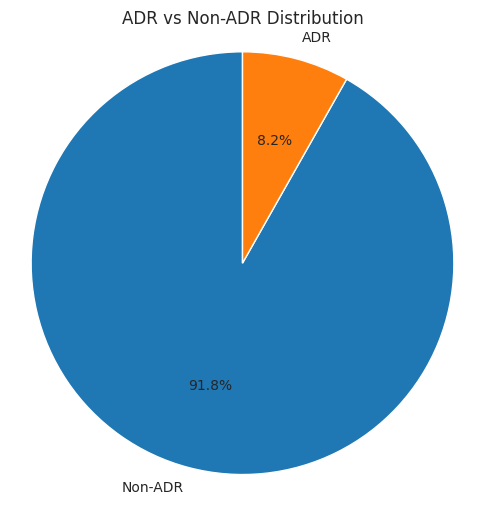

In [7]:
# ADR distribution
print("=" * 80)
print("ADR DISTRIBUTION")
print("=" * 80)
adr_counts = sharadar_metadata['is_adr'].value_counts()
print(f"Non-ADRs: {adr_counts.get(0, 0):,}")
print(f"ADRs: {adr_counts.get(1, 0):,}")

# Plot
plt.figure(figsize=(6, 6))
labels = ['Non-ADR', 'ADR']
sizes = [adr_counts.get(0, 0), adr_counts.get(1, 0)]
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('ADR vs Non-ADR Distribution')
plt.axis('equal')
plt.show()

SECTOR DISTRIBUTION
sector
Industrials               4315
Technology                3703
Healthcare                3262
Financial Services        3110
Consumer Cyclical         2058
Communication Services    1241
Real Estate               1099
Basic Materials           1052
Energy                     969
Consumer Defensive         843
Utilities                  425
Name: count, dtype: int64


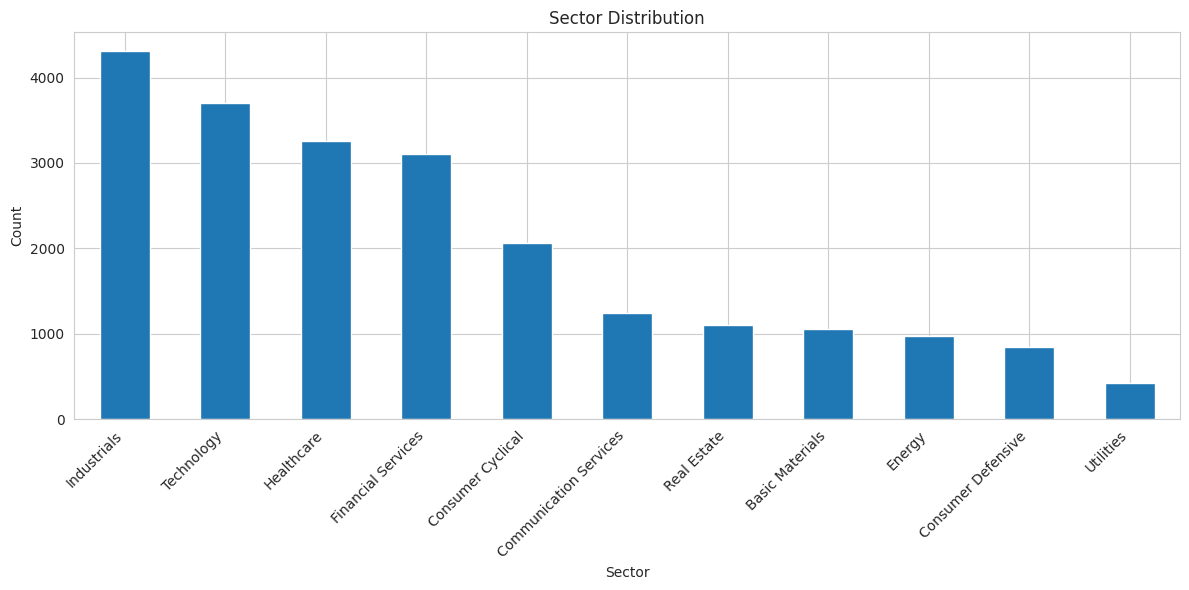

In [8]:
# Sector distribution
if 'sector' in sharadar_metadata.columns:
    print("=" * 80)
    print("SECTOR DISTRIBUTION")
    print("=" * 80)
    print(sharadar_metadata['sector'].value_counts())
    
    # Plot
    plt.figure(figsize=(12, 6))
    sharadar_metadata['sector'].value_counts().plot(kind='bar')
    plt.title('Sector Distribution')
    plt.xlabel('Sector')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

MARKET CAP SCALE DISTRIBUTION
scalemarketcap
1 - Nano     1544
2 - Micro    4493
3 - Small    6155
4 - Mid      3389
5 - Large    1741
6 - Mega       93
Name: count, dtype: int64


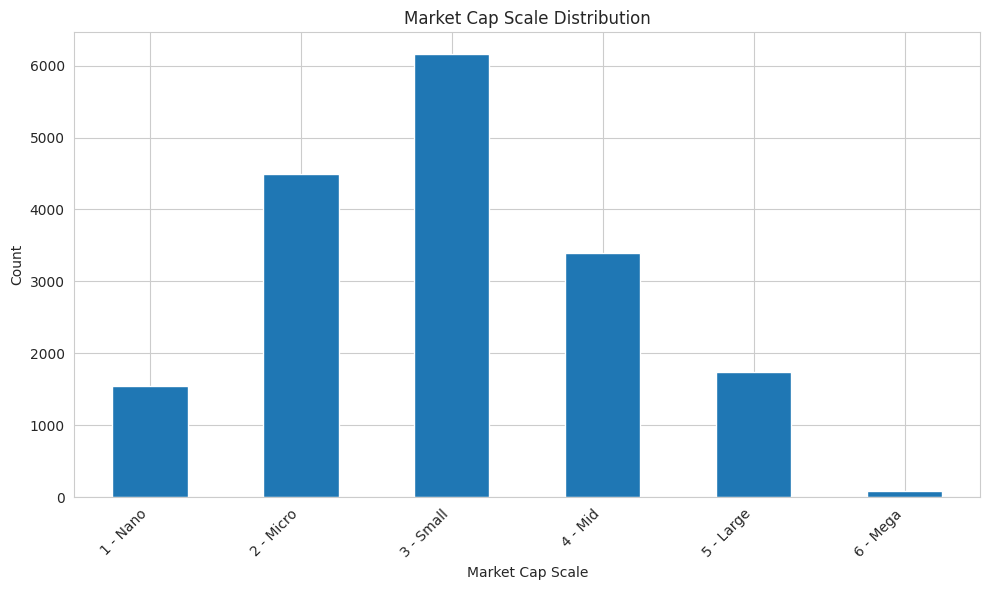

In [9]:
# Market cap scale distribution
if 'scalemarketcap' in sharadar_metadata.columns:
    print("=" * 80)
    print("MARKET CAP SCALE DISTRIBUTION")
    print("=" * 80)
    print(sharadar_metadata['scalemarketcap'].value_counts().sort_index())
    
    # Plot
    plt.figure(figsize=(10, 6))
    sharadar_metadata['scalemarketcap'].value_counts().sort_index().plot(kind='bar')
    plt.title('Market Cap Scale Distribution')
    plt.xlabel('Market Cap Scale')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 4. Load LSEG Fundamentals CSV

In [10]:
# Load LSEG fundamentals
print(f"Loading LSEG fundamentals from: {INPUT_CSV}")
fundamentals = pd.read_csv(INPUT_CSV)

print(f"\nLoaded {len(fundamentals):,} rows, {len(fundamentals.columns)} columns")
print(f"\nColumns: {list(fundamentals.columns)}")

if 'Date' in fundamentals.columns:
    print(f"\nDate range: {fundamentals['Date'].min()} to {fundamentals['Date'].max()}")
    print(f"Unique dates: {fundamentals['Date'].nunique():,}")

if 'Symbol' in fundamentals.columns:
    print(f"Unique symbols: {fundamentals['Symbol'].nunique():,}")

print(f"\nFirst 5 rows:")
fundamentals.tail()

Loading LSEG fundamentals from: /data/csv/20091231_20260113.csv



Loaded 9,123,306 rows, 38 columns

Columns: ['Date', 'Symbol', 'Instrument', 'RefPriceClose', 'RefVolume', 'CompanyCommonName', 'EnterpriseValue_DailyTimeSeries_', 'CompanyMarketCap', 'GICSSectorName', 'FOCFExDividends_Discrete', 'InterestExpense_NetofCapitalizedInterest', 'Debt_Total', 'EarningsPerShare_Actual', 'EarningsPerShare_SmartEstimate_prev_Q', 'EarningsPerShare_ActualSurprise', 'EarningsPerShare_SmartEstimate_current_Q', 'LongTermGrowth_Mean', 'PriceTarget_Median', 'CombinedAlphaModelSectorRank', 'CombinedAlphaModelSectorRankChange', 'CombinedAlphaModelRegionRank', 'EarningsQualityRegionRank_Current', 'EnterpriseValueToEBIT_DailyTimeSeriesRatio_', 'EnterpriseValueToEBITDA_DailyTimeSeriesRatio_', 'EnterpriseValueToSales_DailyTimeSeriesRatio_', 'Dividend_Per_Share_SmartEstimate', 'CashCashEquivalents_Total', 'ForwardPEG_DailyTimeSeriesRatio_', 'PriceEarningsToGrowthRatio_SmartEstimate_', 'Recommendation_Median_1_5_', 'ReturnOnEquity_SmartEstimat', 'ReturnOnAssets_SmartEstimate


Date range: 2008-10-16 to 2026-01-13
Unique dates: 4,049


Unique symbols: 4,492

First 5 rows:


,Date,Symbol,Instrument,RefPriceClose,RefVolume,CompanyCommonName,EnterpriseValue_DailyTimeSeries_,CompanyMarketCap,GICSSectorName,FOCFExDividends_Discrete,InterestExpense_NetofCapitalizedInterest,Debt_Total,EarningsPerShare_Actual,EarningsPerShare_SmartEstimate_prev_Q,EarningsPerShare_ActualSurprise,EarningsPerShare_SmartEstimate_current_Q,LongTermGrowth_Mean,PriceTarget_Median,CombinedAlphaModelSectorRank,CombinedAlphaModelSectorRankChange,CombinedAlphaModelRegionRank,EarningsQualityRegionRank_Current,EnterpriseValueToEBIT_DailyTimeSeriesRatio_,EnterpriseValueToEBITDA_DailyTimeSeriesRatio_,EnterpriseValueToSales_DailyTimeSeriesRatio_,Dividend_Per_Share_SmartEstimate,CashCashEquivalents_Total,ForwardPEG_DailyTimeSeriesRatio_,PriceEarningsToGrowthRatio_SmartEstimate_,Recommendation_Median_1_5_,ReturnOnEquity_SmartEstimat,ReturnOnAssets_SmartEstimate,ForwardPriceToCashFlowPerShare_DailyTimeSeriesRatio_,ForwardPriceToSalesPerShare_DailyTimeSeriesRatio_,ForwardEnterpriseValueToOperatingCashFlow_DailyTimeSeriesRatio_,GrossProfitMargin_ActualSurprise,Estpricegrowth_percent,TradeDate
9123301,2026-01-13,ZUMZ,ZUMZ.OQ,24.81,122160.0,Zumiez Inc,3.160520e+08,4.205190e+08,Consumer Discretionary,3087000.0,NaN,900000.0,0.55,0.26686,107.289,1.06578,15.000,24.0,96.0,38.0,95.0,92.0,21.890292,8.758058,0.344693,NaN,56485000.0,19.932741,0.047869,3.0,3.600,11.9,9.518936,0.444393,7.154204,3.259,-0.032648,2026-01-13
9123302,2026-01-13,ZURA,ZURA.OQ,5.16,76401.0,Zura Bio Ltd,2.513765e+08,3.801925e+08,Health Care,-15476000.0,NaN,990000.0,-0.21,-0.16661,-15.747,-0.20768,NaN,15.5,26.0,-14.0,15.0,29.0,NaN,NaN,NaN,NaN,139017000.0,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,2.003876,2026-01-13
9123303,2026-01-13,ZVRA,ZVRA.OQ,8.92,425168.0,Zevra Therapeutics Inc,3.639750e+08,5.021740e+08,Health Care,4155000.0,2051000.0,59504000.0,-0.01,-0.03597,71.429,0.05323,NaN,24.0,72.0,43.0,68.0,64.0,NaN,NaN,4.313113,NaN,54439000.0,NaN,3.344896,2.0,5.300,NaN,11.291139,3.484219,8.183802,3.114,1.690583,2026-01-13
9123304,2026-01-13,ZWS,ZWS.N,46.16,338687.0,Zurn Elkay Water Solutions Corp,7.961214e+09,7.724914e+09,Industrials,93900000.0,7100000.0,495600000.0,0.43,0.39687,8.430,0.34193,14.485,52.0,49.0,20.0,43.0,79.0,28.740844,21.710427,4.797646,0.10431,260100000.0,1.995319,9.533033,3.0,15.600,NaN,21.620609,4.338176,22.281969,36.763,0.126516,2026-01-13
9123305,2026-01-13,ZYME,ZYME.OQ,23.92,295386.0,Zymeworks Inc,1.538157e+09,1.790090e+09,Health Care,-31822000.0,NaN,56000.0,-0.26,-0.28893,19.036,-0.47234,NaN,34.0,75.0,31.0,72.0,5.0,2.772842,2.648218,11.437726,NaN,64834000.0,NaN,0.257874,2.0,-49.983,NaN,18.542636,7.722229,15.932989,NaN,0.421405,2026-01-13


## 5. Merge Metadata with Fundamentals

In [11]:
# Merge
enriched = add_metadata_to_fundamentals(fundamentals, sharadar_metadata)

print(f"\n{'='*80}")
print("ENRICHED DATA SUMMARY")
print(f"{'='*80}")
print(f"Original columns: {len(fundamentals.columns)}")
print(f"Enriched columns: {len(enriched.columns)}")
print(f"Metadata columns added: {len([c for c in enriched.columns if c.startswith('sharadar_')])}")


Merging metadata...
Fundamentals shape: (9123306, 38)
Metadata shape: (31093, 10)


Merged shape: (9123306, 47)



Matching statistics:
  Total rows: 9,123,306
  Unique symbols: 4,492
  Rows with metadata: 8,704,153 (95.4%)



ENRICHED DATA SUMMARY
Original columns: 38
Enriched columns: 47
Metadata columns added: 9


## 6. Preview Enriched Data

In [12]:
# Show preview with metadata columns
metadata_cols = [col for col in enriched.columns if col.startswith('sharadar_')]
preview_cols = ['Date', 'Symbol'] + metadata_cols
preview_cols = [col for col in preview_cols if col in enriched.columns]

print("=" * 80)
print("PREVIEW (first 10 rows with metadata):")
print("=" * 80)
print(enriched[preview_cols].tail(10).to_string())

PREVIEW (first 10 rows with metadata):


               Date Symbol sharadar_exchange                    sharadar_category         sharadar_location     sharadar_sector                         sharadar_industry                 sharadar_sicsector                                sharadar_sicindustry sharadar_scalemarketcap  sharadar_is_adr
9123296  2026-01-13   ZION            NASDAQ  Domestic Common Stock Primary Class               Utah; U.S.A  Financial Services                          Banks - Regional  Finance Insurance And Real Estate                           National Commercial Banks               5 - Large                0
9123297  2026-01-13     ZM            NASDAQ                Domestic Common Stock         California; U.S.A          Technology                    Software - Application                           Services  Services-Computer Programming Data Processing Etc.               5 - Large                0
9123298  2026-01-13     ZS            NASDAQ                Domestic Common Stock         California; U.S.

In [13]:
# Metadata column summary
print("\n" + "=" * 80)
print("METADATA COLUMN SUMMARY")
print("=" * 80)

for col in sorted(metadata_cols):
    unique_count = enriched[col].nunique()
    null_count = enriched[col].isna().sum()
    empty_count = (enriched[col] == '').sum()
    print(f"{col:40s}: {unique_count:6,} unique, {null_count:8,} nulls, {empty_count:8,} empty")


METADATA COLUMN SUMMARY


sharadar_category                       :     13 unique,        0 nulls,  419,153 empty


sharadar_exchange                       :      7 unique,        0 nulls,  419,153 empty


sharadar_industry                       :    145 unique,        0 nulls, 1,066,627 empty
sharadar_is_adr                         :      2 unique,        0 nulls,        0 empty


sharadar_location                       :     74 unique,        0 nulls,  437,633 empty


sharadar_scalemarketcap                 :      7 unique,        0 nulls, 1,088,365 empty


sharadar_sector                         :     12 unique,        0 nulls, 1,066,627 empty


sharadar_sicindustry                    :    367 unique,        0 nulls, 1,050,736 empty


sharadar_sicsector                      :     10 unique,        0 nulls, 1,050,736 empty


In [14]:
# Sample specific symbols to verify metadata
print("\n" + "=" * 80)
print("SAMPLE SYMBOLS WITH METADATA")
print("=" * 80)

sample_symbols = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']
available_samples = [s for s in sample_symbols if s in enriched['Symbol'].values]

if available_samples:
    sample_data = enriched[enriched['Symbol'].isin(available_samples)][preview_cols].drop_duplicates('Symbol')
    print(sample_data.to_string())
else:
    print("None of the sample symbols found in data")


SAMPLE SYMBOLS WITH METADATA


              Date Symbol sharadar_exchange                    sharadar_category  sharadar_location         sharadar_sector               sharadar_industry sharadar_sicsector                                sharadar_sicindustry sharadar_scalemarketcap  sharadar_is_adr
26      2009-12-31   AAPL            NASDAQ                Domestic Common Stock  California; U.S.A              Technology            Consumer Electronics      Manufacturing                                Electronic Computers                6 - Mega                0
101     2009-12-31   AMZN            NASDAQ                Domestic Common Stock  Washington; U.S.A       Consumer Cyclical                 Internet Retail       Retail Trade                  Retail-Catalog & Mail-Order Houses                6 - Mega                0
636     2009-12-31  GOOGL            NASDAQ  Domestic Common Stock Primary Class  California; U.S.A  Communication Services  Internet Content & Information           Services  Services-Computer Pr

## 7. Metadata Distribution in Enriched Data

In [15]:
# Get unique symbol-level data for analysis
unique_symbols = enriched[['Symbol'] + metadata_cols].drop_duplicates('Symbol')

print(f"Analyzing {len(unique_symbols):,} unique symbols")

Analyzing 4,492 unique symbols


EXCHANGE DISTRIBUTION (in enriched data)
sharadar_exchange
NASDAQ      2025
NYSE        1872
             474
NYSEMKT       68
NYSEARCA      44
BATS           6
OTC            3
Name: count, dtype: int64


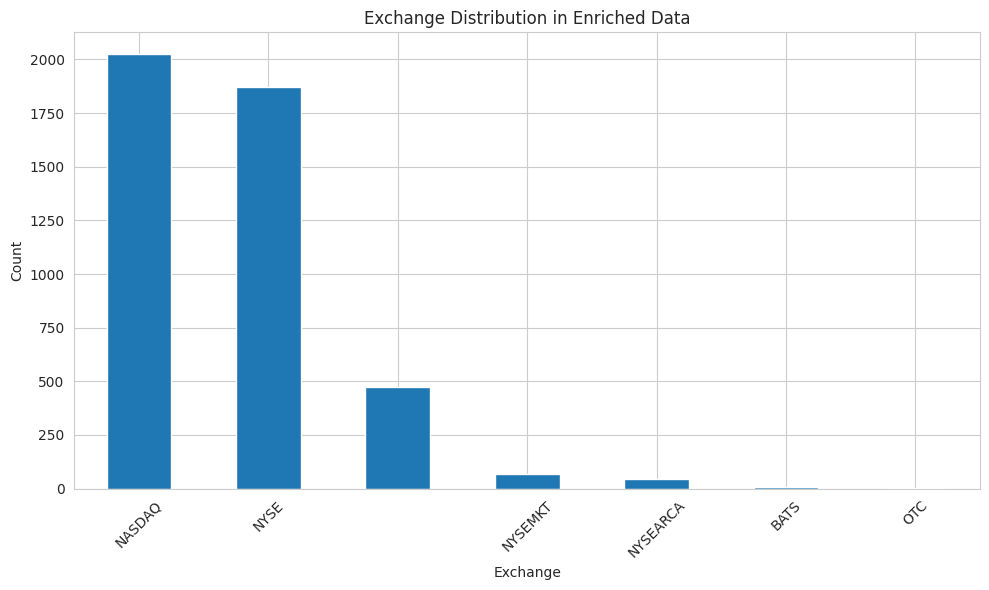

In [16]:
# Exchange distribution in enriched data
if 'sharadar_exchange' in unique_symbols.columns:
    print("=" * 80)
    print("EXCHANGE DISTRIBUTION (in enriched data)")
    print("=" * 80)
    exchange_dist = unique_symbols['sharadar_exchange'].value_counts()
    print(exchange_dist)
    
    # Plot
    plt.figure(figsize=(10, 6))
    exchange_dist.head(10).plot(kind='bar')
    plt.title('Exchange Distribution in Enriched Data')
    plt.xlabel('Exchange')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

CATEGORY DISTRIBUTION (in enriched data)
sharadar_category
Domestic Common Stock                    2746
Domestic Common Stock Primary Class       882
                                          474
CEF                                       258
ETF                                        58
Domestic Common Stock Secondary Class      30
ADR Common Stock                           20
ADR Common Stock Primary Class             12
Domestic Preferred Stock                    4
Canadian Common Stock                       3
UNIT                                        2
ETD                                         2
ADR Common Stock Secondary Class            1
Name: count, dtype: int64


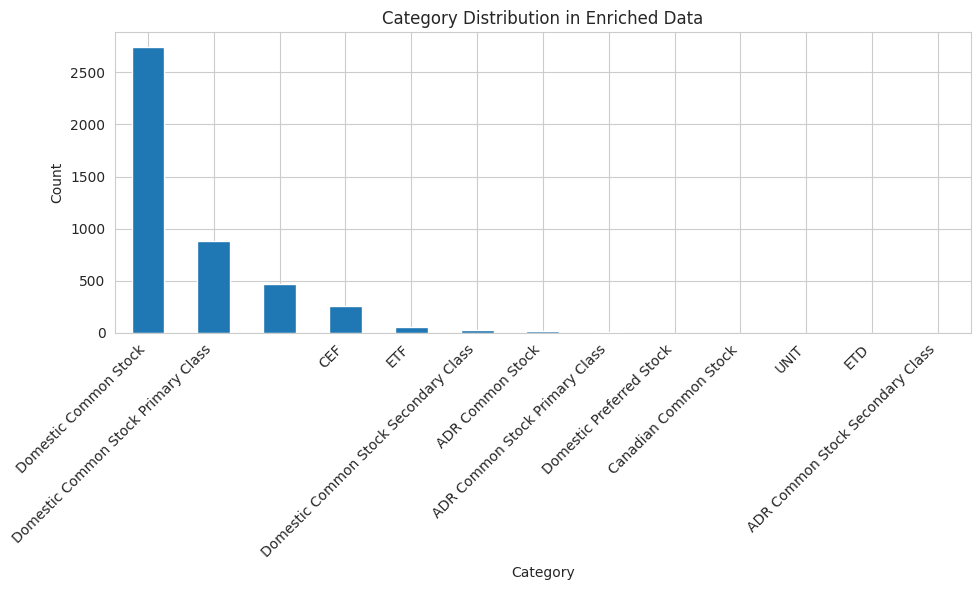

In [17]:
# Category distribution in enriched data
if 'sharadar_category' in unique_symbols.columns:
    print("=" * 80)
    print("CATEGORY DISTRIBUTION (in enriched data)")
    print("=" * 80)
    category_dist = unique_symbols['sharadar_category'].value_counts()
    print(category_dist)
    
    # Plot
    plt.figure(figsize=(10, 6))
    category_dist.plot(kind='bar')
    plt.title('Category Distribution in Enriched Data')
    plt.xlabel('Category')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

SECTOR DISTRIBUTION (in enriched data)
sharadar_sector
                          796
Healthcare                686
Industrials               675
Financial Services        544
Technology                520
Consumer Cyclical         357
Real Estate               219
Energy                    172
Basic Materials           166
Consumer Defensive        139
Communication Services    134
Utilities                  84
Name: count, dtype: int64


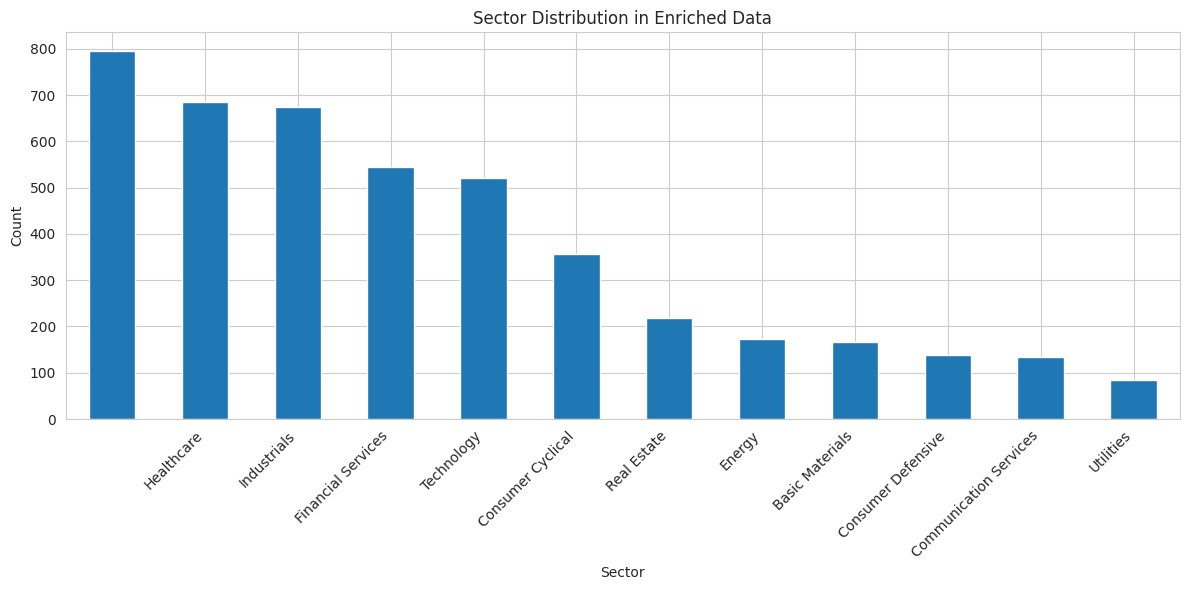

In [18]:
# Sector distribution in enriched data
if 'sharadar_sector' in unique_symbols.columns:
    print("=" * 80)
    print("SECTOR DISTRIBUTION (in enriched data)")
    print("=" * 80)
    sector_dist = unique_symbols['sharadar_sector'].value_counts()
    print(sector_dist)
    
    # Plot
    plt.figure(figsize=(12, 6))
    sector_dist.plot(kind='bar')
    plt.title('Sector Distribution in Enriched Data')
    plt.xlabel('Sector')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 8. Save Enriched CSV

In [19]:
# Save enriched data
print(f"Saving enriched data to: {OUTPUT_CSV}")
enriched.to_csv(OUTPUT_CSV, index=False)

print(f"\n✓ Saved {len(enriched):,} rows to {OUTPUT_CSV}")

Saving enriched data to: /data/csv/20091231_20260113_with_metadata.csv



✓ Saved 9,123,306 rows to /data/csv/20091231_20260113_with_metadata.csv


## 9. Summary Report

In [20]:
print("\n" + "=" * 80)
print("FINAL SUMMARY")
print("=" * 80)
print(f"Original columns: {len(fundamentals.columns)}")
print(f"Enriched columns: {len(enriched.columns)}")
print(f"Metadata columns added: {len(metadata_cols)}")

print("\nNew metadata columns:")
for col in sorted(metadata_cols):
    print(f"  - {col}")

print("\n" + "=" * 80)
print("NEXT STEPS")
print("=" * 80)
print(f"1. Load the enriched CSV into fundamentals.sqlite:")
print(f"   python examples/lseg_fundamentals/load_csv_fundamentals.py")
print(f"")
print(f"2. Use the metadata columns in your Pipeline strategies:")
print(f"   - Filter by exchange: sharadar_exchange")
print(f"   - Filter by category: sharadar_category")
print(f"   - Exclude ADRs: sharadar_is_adr == 0")
print(f"   - Filter by sector: sharadar_sector")
print(f"   - Filter by market cap scale: sharadar_scalemarketcap")
print(f"")
print(f"3. Example Pipeline filter:")
print(f"   exchange_filter = (CustomFundamentals.sharadar_exchange.latest == 'NYSE')")
print(f"   category_filter = (CustomFundamentals.sharadar_category.latest == 'Domestic Common Stock')")
print(f"   no_adr_filter = (CustomFundamentals.sharadar_is_adr.latest == 0)")
print(f"   universe = exchange_filter & category_filter & no_adr_filter")
print("\n✓ Done!")


FINAL SUMMARY
Original columns: 38
Enriched columns: 47
Metadata columns added: 9

New metadata columns:
  - sharadar_category
  - sharadar_exchange
  - sharadar_industry
  - sharadar_is_adr
  - sharadar_location
  - sharadar_scalemarketcap
  - sharadar_sector
  - sharadar_sicindustry
  - sharadar_sicsector

NEXT STEPS
1. Load the enriched CSV into fundamentals.sqlite:
   python examples/lseg_fundamentals/load_csv_fundamentals.py

2. Use the metadata columns in your Pipeline strategies:
   - Filter by exchange: sharadar_exchange
   - Filter by category: sharadar_category
   - Exclude ADRs: sharadar_is_adr == 0
   - Filter by sector: sharadar_sector
   - Filter by market cap scale: sharadar_scalemarketcap

3. Example Pipeline filter:
   exchange_filter = (CustomFundamentals.sharadar_exchange.latest == 'NYSE')
   category_filter = (CustomFundamentals.sharadar_category.latest == 'Domestic Common Stock')
   no_adr_filter = (CustomFundamentals.sharadar_is_adr.latest == 0)
   universe = exc

## 10. Sample Data for AAPL

View the last 10 rows of enriched data for AAPL to see all columns with metadata.

In [21]:
# Get last 10 rows for AAPL
print("=" * 80)
print("LAST 10 ROWS FOR AAPL (with all columns)")
print("=" * 80)

if 'AAPL' in enriched['Symbol'].values:
    aapl_data = enriched[enriched['Symbol'] == 'AAPL'].tail(10)
    
    print(f"\nShowing last 10 rows of {len(enriched[enriched['Symbol'] == 'AAPL'])} total rows for AAPL")
    print(f"Date range: {aapl_data['Date'].min()} to {aapl_data['Date'].max()}")
    print(f"\nColumns: {len(aapl_data.columns)}")
    print("\n" + "=" * 80)
    
    # Display with pandas settings for full visibility
    with pd.option_context('display.max_columns', None,
                          'display.max_rows', None,
                          'display.width', None,
                          'display.max_colwidth', 50):
        print(aapl_data)
    
    print("\n" + "=" * 80)
    print("AAPL METADATA SUMMARY")
    print("=" * 80)
    
    # Show just the metadata columns for clarity
    metadata_cols_display = [col for col in aapl_data.columns if col.startswith('sharadar_')]
    if metadata_cols_display:
        aapl_metadata = aapl_data[['Date', 'Symbol'] + metadata_cols_display].tail(1)
        print("\nSharadar Metadata for AAPL:")
        for col in metadata_cols_display:
            value = aapl_metadata[col].iloc[0]
            print(f"  {col:40s}: {value}")
else:
    print("AAPL not found in enriched data")

LAST 10 ROWS FOR AAPL (with all columns)



Showing last 10 rows of 4033 total rows for AAPL
Date range: 2025-12-30 to 2026-01-13

Columns: 47

               Date Symbol Instrument  RefPriceClose   RefVolume  \
9093550  2025-12-30   AAPL    AAPL.OQ         273.08   9626991.0   
9096558  2025-12-31   AAPL    AAPL.OQ         271.86  12679708.0   
9099546  2026-01-02   AAPL    AAPL.OQ         271.01  14240426.0   
9102526  2026-01-05   AAPL    AAPL.OQ         267.26  17450895.0   
9105507  2026-01-06   AAPL    AAPL.OQ         262.36  19711949.0   
9108490  2026-01-07   AAPL    AAPL.OQ         260.33  15152254.0   
9111459  2026-01-08   AAPL    AAPL.OQ         259.04  16524279.0   
9114428  2026-01-09   AAPL    AAPL.OQ         259.37  13953523.0   
9117400  2026-01-12   AAPL    AAPL.OQ         260.25  18135059.0   
9120360  2026-01-13   AAPL    AAPL.OQ         261.05  17329857.0   

        CompanyCommonName  EnterpriseValue_DailyTimeSeries_  CompanyMarketCap  \
9093550         Apple Inc                      4.080316e+12      4.03